# Ensembling for Dataset B

In [12]:
import pandas as pd
import numpy as np
import datetime
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tcn import TCN
import time

In [ ]:
# ------------------- DATA PREP -------------------
df = pd.read_csv("D:/SELC_AD/Code/paper_code/data/Dataset_B.csv", index_col='DateTime', parse_dates=True)
df = df[df['LCLid'] == 'MAC000003']

df.columns = df.columns.str.strip()
df.rename(columns={'KWH/hh (per half hour)': 'kwh'}, inplace=True)
df['kwh'] = pd.to_numeric(df['kwh'].astype(str).str.strip(), errors='coerce')
df = df.ffill()

In [ ]:
data = df["kwh"].to_numpy().reshape((len(df["kwh"]), 1))
mean_data = np.mean(data)
std_data = np.std(data)
data_normalized = (data - mean_data) / std_data if std_data != 0 else data - mean_data
print(mean_data)
print(std_data)

In [ ]:
def truncate(x, feature_cols=range(1), target_cols=range(1), train_len=48, test_len=1):
    in_, out_ = [], []
    for i in range(len(x) - train_len - test_len + 1):
        in_.append(x[i:(i + train_len), feature_cols].tolist())
        out_.append(x[(i + train_len):(i + train_len + test_len), target_cols].tolist())
    return np.array(in_), np.array(out_)

X_in, X_out = truncate(data_normalized, feature_cols=range(1), target_cols=range(1), train_len=48, test_len=1) # meter 03
# X_in, X_out = truncate(data_normalized, feature_cols=range(1), target_cols=range(1), train_len=48, test_len=1) # meter 06
print(X_in.shape, X_out.shape)

In [16]:
n = X_in.shape[0]
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_x, val_x, test_x = X_in[:train_end], X_in[train_end:val_end], X_in[val_end:]
train_y, val_y, test_y = X_out[:train_end], X_out[train_end:val_end], X_out[val_end:]
train_y = np.repeat(train_y, 2, axis=1)
val_y = np.repeat(val_y, 2, axis=1)
test_y = np.repeat(test_y, 2, axis=1)

In [17]:

# ------------------- LOSS FUNCTION -------------------
q = 0.95
l = 2

r = 0.4 # meter 03
delta = 0.005 # meter 03

def confidence_loss(y_true, y_pred):
    y_true = y_true[:, 0]
    f1, f2 = y_pred[:, 0], y_pred[:, 1]
    c1 = (1 - q) * (y_true - f2)
    c2 = (1 - q) * (f1 - y_true)
    c3 = q * (f2 - y_true)
    c4 = q * (y_true - f1)
    loss = tf.where(tf.math.logical_and(y_true <= f1, y_true >= f2),
                    tf.where(y_true > r * (f1 + f2), c1, c2),
                    tf.where(f2 > y_true, c3, c4)) + (delta * tf.math.abs(f1 - f2))
    return loss

In [18]:
# ------------------- MODEL -------------------
def build_tcn_model(input_shape, num_outputs=2):
    inputs = Input(shape=input_shape)
    x = TCN(nb_filters=64, kernel_size=3, nb_stacks=1, dilations=(1, 2, 4, 8),
            dropout_rate=0.3, return_sequences=False)(inputs)
    outputs = Dense(num_outputs)(x)
    return Model(inputs, outputs)


In [21]:
# ------------------- ENSEMBLE TRAINING -------------------
results = []
batch_size = 64

for run in range(1, 6):
    print(f"\n===== RUN {run} =====")
    tf.keras.utils.set_random_seed(run)  # different seed for each run

    model = build_tcn_model(input_shape=(train_x.shape[1], train_x.shape[2]))
    model.compile(loss=confidence_loss, optimizer=Adam(learning_rate=0.001))

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, mode='min')
    start_time = datetime.datetime.now()

    model.fit(train_x, train_y, validation_data=(val_x, val_y),
              epochs=100, batch_size=batch_size, verbose=1, callbacks=[early_stopping])

    end_time = datetime.datetime.now()
    total_time = end_time - start_time
    print('seconds taken:', round(total_time.total_seconds(), 1),
            '\nstart_time:', start_time.strftime('%H:%M:%S'),
            'end_time:', end_time.strftime('%H:%M:%S'))

    # ----- Validation -----
    val_pred = model.predict(val_x, verbose=0)
    val_y_true = np.squeeze(val_y[:, 0]) * std_data + mean_data
    val_u = val_pred[:, 0] * std_data + mean_data
    val_l = val_pred[:, 1] * std_data + mean_data
  
    # ----- Test -----
    test_pred = model.predict(test_x, verbose=0)
    test_y_true = np.squeeze(test_y[:, 0]) * std_data + mean_data
    test_u = test_pred[:, 0] * std_data + mean_data
    test_l = test_pred[:, 1] * std_data + mean_data
    np.save(f"TCN_TUBE_UK_test_upper_run{run}_dtB.npy", test_u)
    np.save(f"TCN_TUBE_UK_test_lower_run{run}_dtB.npy", test_l)

    # Metrics
    val_picp = np.mean((val_u > val_y_true) * (val_l < val_y_true))
    val_mpiw = np.mean(val_u - val_l)
    test_picp = np.mean((test_u > test_y_true) * (test_l < test_y_true))
    test_mpiw = np.mean(test_u - test_l)

    results.append({
        "Training Time (s)": total_time,
        "Run": run,
        "Val_PICP": val_picp,
        "Val_MPIW": val_mpiw,
        "Test_PICP": test_picp,
        "Test_MPIW": test_mpiw
    })



===== RUN 1 =====
Epoch 1/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.9799 - val_loss: 0.0855
Epoch 2/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.1146 - val_loss: 0.0607
Epoch 3/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0894 - val_loss: 0.0539
Epoch 4/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0787 - val_loss: 0.0508
Epoch 5/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0728 - val_loss: 0.0485
Epoch 6/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0692 - val_loss: 0.0482
Epoch 7/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0665 - val_loss: 0.0467
Epoch 8/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0643 - val_loss: 0.0452
Epoch 9/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0623 - val_loss: 0.0447
Epoch 10/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0614 - val_loss: 0.0462
Epoch 11/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0595 - val_loss: 0.0450
Epoch 12/10

In [ ]:
# ================== Save results ==================
results_df = pd.DataFrame(results)
results_df.to_excel("ensemble_results_dtB.xlsx", index=False)
print("\nResults saved to Excel.")

In [23]:

# ================== Save test data ==================
np.save("test_X_dtB.npy", test_x)
np.save("test_y_dtB.npy", test_y)


## Computing new PICP and MPIW (AFTER ENSEMBLING)

In [35]:
# Path where bounds are stored
base_path = ""
runs = 5

In [36]:
# Load test_y

import os

test_y = np.load(os.path.join(base_path, "test_y_dtB.npy"))

# Storage for all runs
all_upper = []
all_lower = []

In [37]:
# Load bounds from each run
for run in range(1, runs+1):
    lower_bounds = np.load(os.path.join(base_path, f"TCN_TUBE_UK_test_lower_run{run}_dtB.npy"))
    upper_bounds = np.load(os.path.join(base_path, f"TCN_TUBE_UK_test_upper_run{run}_dtB.npy"))
    
    all_lower.append(lower_bounds)
    all_upper.append(upper_bounds)

In [38]:

# Convert to arrays: shape = (runs, num_samples)
all_lower = np.array(all_lower)
all_upper = np.array(all_upper)

# Mean across runs (axis=0 → average over runs)
mean_lower = np.mean(all_lower, axis=0)
mean_upper = np.mean(all_upper, axis=0)

In [39]:
# Std. deviation (sigma) across runs
sigma_lower = np.std(all_lower, axis=0, ddof=1)  # ddof=1 for sample std
sigma_upper = np.std(all_upper, axis=0, ddof=1)

In [ ]:
print(np.mean(sigma_lower))
print(np.mean(sigma_upper))

In [41]:
# Calculate new bounds using formula
factor = 1.96 * (1 / np.sqrt(runs))
new_upper = mean_upper + factor * sigma_upper
new_lower = mean_lower - factor * sigma_lower

In [42]:
test_y_true = np.squeeze(test_y[:, 0]) * std_data + mean_data

PICP = np.mean((new_upper > test_y_true) * (new_lower < test_y_true))
MPIW = np.mean(new_upper - new_lower)


In [ ]:
print(PICP)
print(MPIW)

# Plots

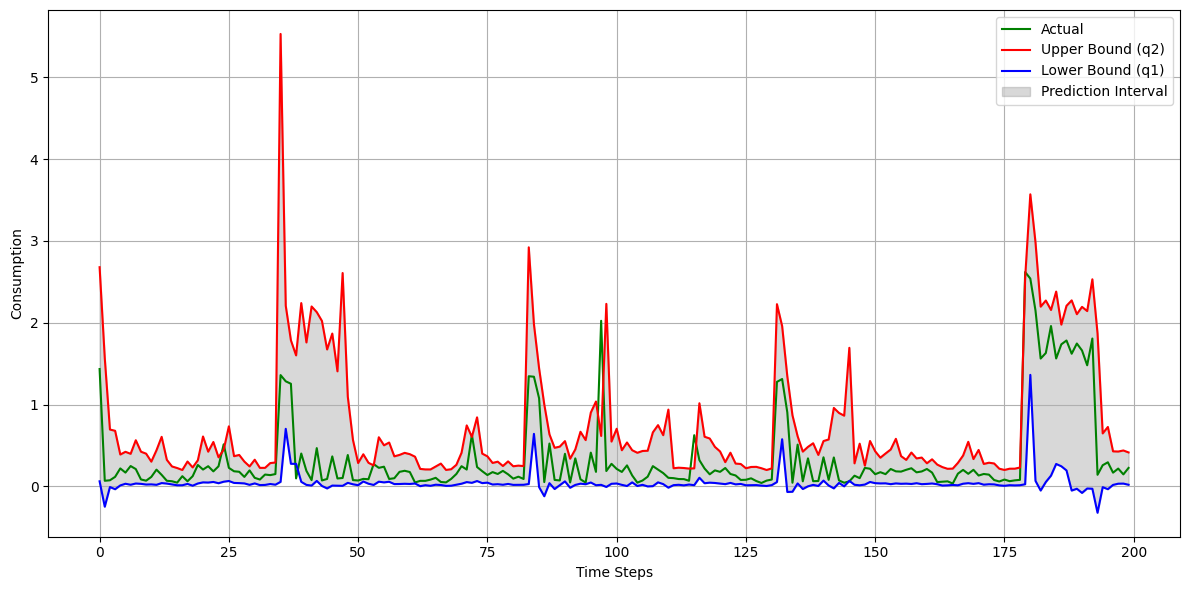

In [ ]:
import matplotlib.pyplot as plt
# Choose a slice — e.g., first 200 points
start = 0
end = 200  # Or any other small window

subset_range = range(start, end)

plt.figure(figsize=(12, 6))
plt.plot(subset_range, test_y_true[start:end], label='Actual', color='green')
plt.plot(subset_range, new_upper[start:end], label='Upper Bound (q2)', color='red')
plt.plot(subset_range, new_lower[start:end], label='Lower Bound (q1)', color='blue')
plt.fill_between(subset_range, new_lower[start:end], new_upper[start:end], color='gray', alpha=0.3, label='Prediction Interval')
plt.xlabel('Time Steps')
plt.ylabel('Consumption')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
